In [1]:
# Intalar pacote
install.packages("tree", repos = "https://cloud.r-project.org/")
library(tree)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [2]:
# Utilizando dados do R (Iris)
data(iris)
dados<-iris
head(dados)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
6,5.4,3.9,1.7,0.4,setosa


In [4]:
# Particionar o conjunto de dados treinamento e validação
iris_setosa<-iris[iris$Species=="setosa",]
iris_versicolor<-iris[iris$Species=="versicolor",]
iris_virginica<-iris[iris$Species=="virginica",]

iris_train<-rbind(iris_setosa[1:25,],iris_versicolor[1:25,],iris_virginica[1:25,])
iris_test<-rbind(iris_setosa[26:50,],iris_versicolor[26:50,],iris_virginica[26:50,])


In [6]:
#Ajuste da árvore

arvore1<-tree(Species ~ Sepal.Width+Sepal.Length+Petal.Length +Petal.Width,data=iris_train)


#Resumo

summary(arvore1)


Classification tree:
tree(formula = Species ~ Sepal.Width + Sepal.Length + Petal.Length + 
    Petal.Width, data = iris_train)
Variables actually used in tree construction:
[1] "Petal.Length" "Petal.Width"  "Sepal.Width" 
Number of terminal nodes:  5 
Residual mean deviance:  0.143 = 10.01 / 70 
Misclassification error rate: 0.02667 = 2 / 75 

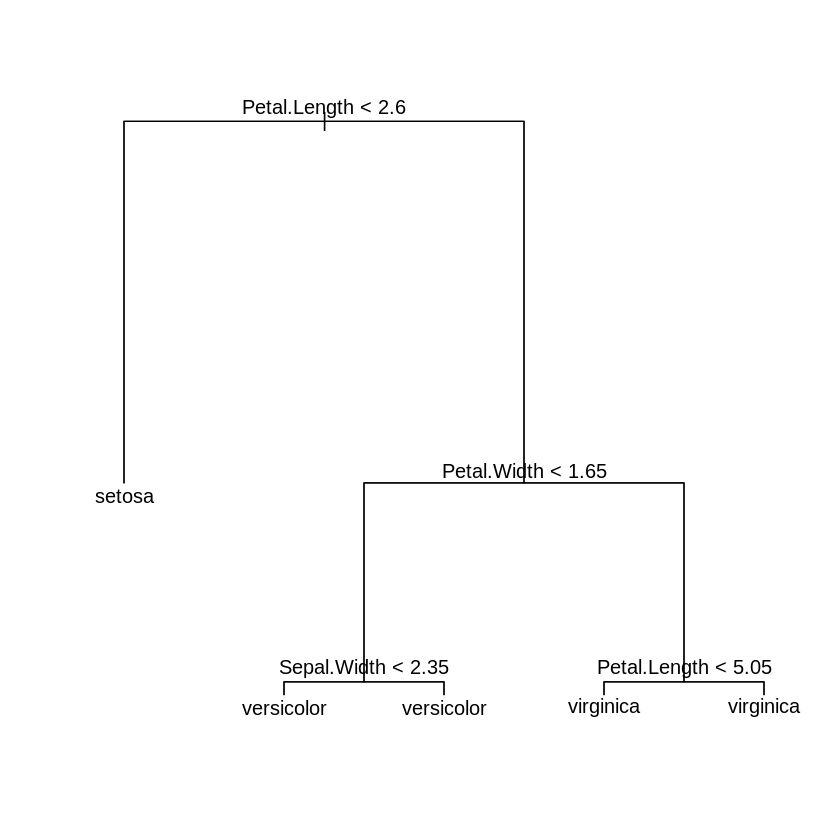

In [7]:
#Apresentação da árvore ajustada

plot(arvore1)
text(arvore1)

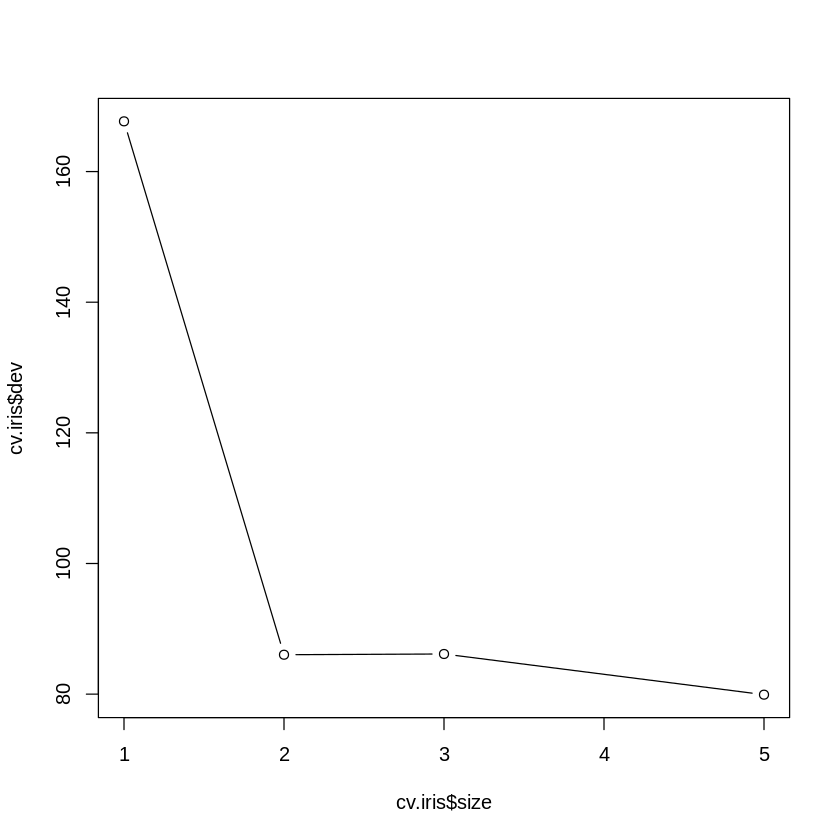

In [8]:
# Verificar se é interessante realizar a poda
#Verificar se é interessante realizar a poda
cv.iris=cv.tree(arvore1)
plot(cv.iris$size ,cv.iris$dev ,type="b")



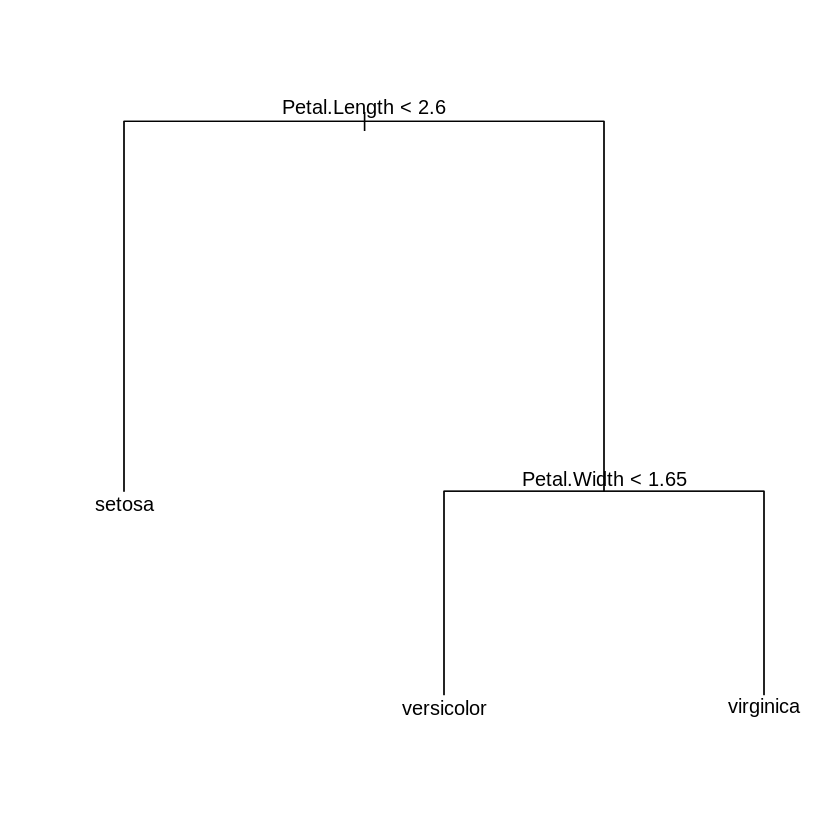

In [11]:
#Se desejar podar
mod_poda=prune.tree(arvore1,best=3)
plot(mod_poda)
text(mod_poda, pretty =0)



In [13]:
#Predição (Considerando o modelo sem poda)

pred_arv <- predict(mod_poda, iris_test, type="class")
head(pred_arv)



[1] setosa setosa setosa setosa setosa setosa
Levels: setosa versicolor virginica

In [16]:
#Medidas de performance (https://topepo.github.io/caret/variable-importance.html)
install.packages("pROC")
install.packages("caret", dependencies = TRUE)



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [17]:
# 1. Carregue o pacote na memória
library(caret)

# 2. Agora a função estará disponível
confusionMatrix(pred_arv, iris_test$Species)


Confusion Matrix and Statistics

            Reference
Prediction   setosa versicolor virginica
  setosa         25          0         0
  versicolor      0         24         3
  virginica       0          1        22

Overall Statistics
                                         
               Accuracy : 0.9467         
                 95% CI : (0.869, 0.9853)
    No Information Rate : 0.3333         
    P-Value [Acc > NIR] : < 2.2e-16      
                                         
                  Kappa : 0.92           
                                         
 Mcnemar's Test P-Value : NA             

Statistics by Class:

                     Class: setosa Class: versicolor Class: virginica
Sensitivity                 1.0000            0.9600           0.8800
Specificity                 1.0000            0.9400           0.9800
Pos Pred Value              1.0000            0.8889           0.9565
Neg Pred Value              1.0000            0.9792           0.9423
Prevalence

In [18]:
#Bagging

#Instalar pacote
#install.packages("randomForest")
library(randomForest)

#Ajuste bagging
bagging <- randomForest(Species~., data=iris_train,  mtry = 4)
bagging

#Avaliação do modelo (Preditivo)
pred_bagg <- predict(bagging, iris_test)
confusionMatrix(pred_bagg, iris_test$Species)



randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:ggplot2’:

    margin





Call:
 randomForest(formula = Species ~ ., data = iris_train, mtry = 4) 
               Type of random forest: classification
                     Number of trees: 500
No. of variables tried at each split: 4

        OOB estimate of  error rate: 4%
Confusion matrix:
           setosa versicolor virginica class.error
setosa         25          0         0        0.00
versicolor      0         24         1        0.04
virginica       0          2        23        0.08

Confusion Matrix and Statistics

            Reference
Prediction   setosa versicolor virginica
  setosa         25          0         0
  versicolor      0         23         2
  virginica       0          2        23

Overall Statistics
                                         
               Accuracy : 0.9467         
                 95% CI : (0.869, 0.9853)
    No Information Rate : 0.3333         
    P-Value [Acc > NIR] : < 2.2e-16      
                                         
                  Kappa : 0.92           
                                         
 Mcnemar's Test P-Value : NA             

Statistics by Class:

                     Class: setosa Class: versicolor Class: virginica
Sensitivity                 1.0000            0.9200           0.9200
Specificity                 1.0000            0.9600           0.9600
Pos Pred Value              1.0000            0.9200           0.9200
Neg Pred Value              1.0000            0.9600           0.9600
Prevalence


Call:
 randomForest(formula = Species ~ ., data = iris_train, mtry = 2) 
               Type of random forest: classification
                     Number of trees: 500
No. of variables tried at each split: 2

        OOB estimate of  error rate: 4%
Confusion matrix:
           setosa versicolor virginica class.error
setosa         25          0         0        0.00
versicolor      0         24         1        0.04
virginica       0          2        23        0.08

Confusion Matrix and Statistics

            Reference
Prediction   setosa versicolor virginica
  setosa         25          0         0
  versicolor      0         23         1
  virginica       0          2        24

Overall Statistics
                                          
               Accuracy : 0.96            
                 95% CI : (0.8875, 0.9917)
    No Information Rate : 0.3333          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.94            
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: setosa Class: versicolor Class: virginica
Sensitivity                 1.0000            0.9200           0.9600
Specificity                 1.0000            0.9800           0.9600
Pos Pred Value              1.0000            0.9583           0.9231
Neg Pred Value              1.0000            0.9608           0.9796
P

,MeanDecreaseGini
Sepal.Length,3.659176
Sepal.Width,1.865302
Petal.Length,21.075399
Petal.Width,22.777723


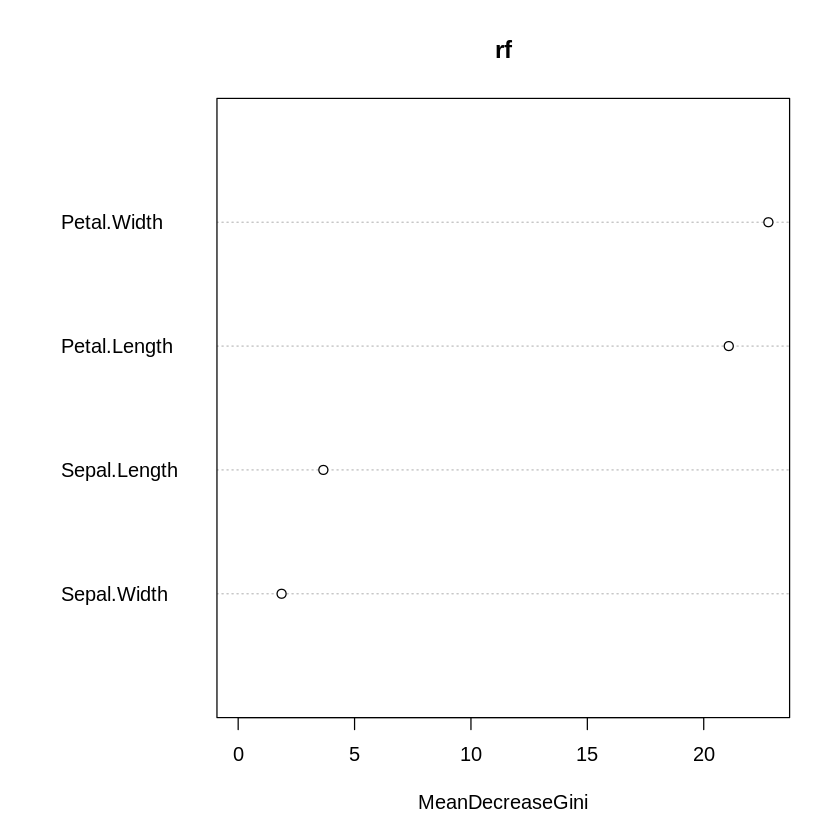

In [19]:
#Random Forest
rf<- randomForest(Species~., data=iris_train,  mtry = 2)
rf

#Avaliação do modelo (Predição)
pred_rf <- predict(rf, iris_test)
confusionMatrix(pred_rf, iris_test$Species)

#Importãncia (Baseado nas amostras out-of_bag)
i_mod_rf <-importance(rf)
i_mod_rf

varImpPlot (rf)
